## Anomaly Detection using Convolutional Autoencoders on Tiny-ImageNet

### Imports

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, Subset
import torch.nn.functional as F

### Loading dataset

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder("/kaggle/input/datasets/saksham23456/tiny-imagenet/train", transform=transform)
test_dataset  = datasets.ImageFolder("/kaggle/input/datasets/saksham23456/tiny-imagenet/test",  transform=transform)

print(f"Classes: {train_dataset.classes}")
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']
Train size: 3500, Test size: 1000


### Holding out one class

In [32]:
OOD_CLASS = 3  # ood class index

train_indices_seen = []
train_indices_unseen = []

for i, (_, label) in enumerate(train_dataset):
    if label == OOD_CLASS:
        train_indices_unseen.append(i)
    else:
        train_indices_seen.append(i)

test_indices_seen = []
test_indices_unseen = []

for i, (_, label) in enumerate(test_dataset):
    if label == OOD_CLASS:
        test_indices_unseen.append(i)
    else:
        test_indices_seen.append(i)

train_seen = Subset(train_dataset, train_indices_seen)
train_unseen = Subset(train_dataset, train_indices_unseen)

test_seen = Subset(test_dataset, test_indices_seen)
test_unseen = Subset(test_dataset, test_indices_unseen)

In [33]:
batch_size = 128

train_loader = DataLoader(train_seen, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader_seen = DataLoader(test_seen, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader_unseen = DataLoader(test_unseen, batch_size=batch_size, shuffle=False, num_workers=4)

### Defining Model architecture

In [34]:
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def encoder(self, x):
        return self.enc(x)

    def decoder(self, x):
        return self.dec(x)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return self.forward(x)

### Defining loss function and optimizer

In [35]:
model = ConvAE().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Training model

In [36]:
losses = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    for imgs, _ in train_loader:
        x = imgs.to(device)
        recon = model(x)
        loss = criterion(recon, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    avg = epoch_loss/len(train_seen)
    losses.append(avg)
    print(f"Epoch {epoch+1}, Loss={avg:.4f}")

Epoch 1, Loss=0.2107
Epoch 2, Loss=0.0924
Epoch 3, Loss=0.0652
Epoch 4, Loss=0.0566
Epoch 5, Loss=0.0525
Epoch 6, Loss=0.0495
Epoch 7, Loss=0.0469
Epoch 8, Loss=0.0445
Epoch 9, Loss=0.0435
Epoch 10, Loss=0.0408
Epoch 11, Loss=0.0403
Epoch 12, Loss=0.0375
Epoch 13, Loss=0.0364
Epoch 14, Loss=0.0371
Epoch 15, Loss=0.0350
Epoch 16, Loss=0.0339
Epoch 17, Loss=0.0333
Epoch 18, Loss=0.0345
Epoch 19, Loss=0.0323
Epoch 20, Loss=0.0318
Epoch 21, Loss=0.0317
Epoch 22, Loss=0.0306
Epoch 23, Loss=0.0308
Epoch 24, Loss=0.0297
Epoch 25, Loss=0.0320
Epoch 26, Loss=0.0298
Epoch 27, Loss=0.0287
Epoch 28, Loss=0.0283
Epoch 29, Loss=0.0282
Epoch 30, Loss=0.0277


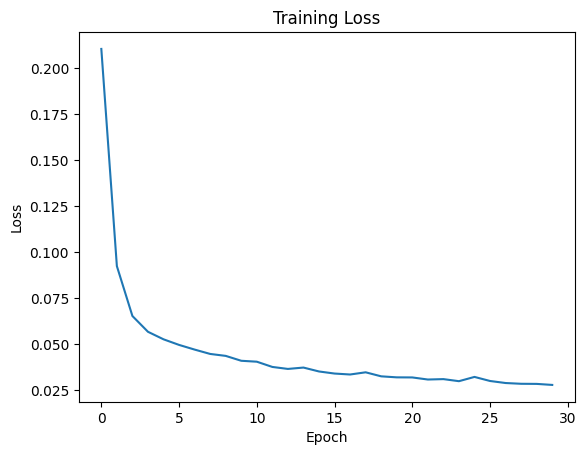

In [37]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

### Calculating reconstruction error for seen and unseen classes

In [38]:
model.eval()

mse_seen = []
mse_unseen = []

with torch.no_grad():
    for imgs, labels in test_loader_seen:
        x = imgs.to(device)
        recon = model(x)
        err = torch.mean((recon - x)**2, dim=(1,2,3))
        mse_seen.extend(err.cpu().numpy())
    for imgs, labels in test_loader_unseen:
        x = imgs.to(device)
        recon = model(x)
        err = torch.mean((recon - x)**2, dim=(1,2,3))
        mse_unseen.extend(err.cpu().numpy())

In [39]:
mse_seen = np.array(mse_seen)
mse_unseen = np.array(mse_unseen)

print("Average reconstruction error for seen class:", mse_seen.mean())
print("Average reconstruction error for unseen class:", mse_unseen.mean())

Average reconstruction error for seen class: 0.028401604
Average reconstruction error for unseen class: 0.016843986


In [40]:
all_losses = []
all_labels = []

with torch.no_grad():

    for imgs, labels in test_loader_seen:
        x = imgs.to(device)
        recon = model(x)
        err = torch.mean((recon - x)**2, dim=(1,2,3))
        all_losses.extend(err.cpu().numpy())
        all_labels.extend(labels.numpy())

    for imgs, labels in test_loader_unseen:
        x = imgs.to(device)
        recon = model(x)
        err = torch.mean((recon - x)**2, dim=(1,2,3))
        all_losses.extend(err.cpu().numpy())
        all_labels.extend(labels.numpy())

all_losses = np.array(all_losses)
all_labels = np.array(all_labels)

digit_losses = {}

for d in range(len(train_dataset.classes)):
    digit_losses[d] = all_losses[all_labels == d].mean()

for d in digit_losses:
    print(f"Class {d}: Avg MSE = {digit_losses[d]:.6f}")

Class 0: Avg MSE = 0.028132
Class 1: Avg MSE = 0.036198
Class 2: Avg MSE = 0.018450
Class 3: Avg MSE = 0.016844
Class 4: Avg MSE = 0.028276
Class 5: Avg MSE = 0.027768
Class 6: Avg MSE = 0.043647
Class 7: Avg MSE = 0.023515
Class 8: Avg MSE = 0.020019
Class 9: Avg MSE = 0.029609


### Plot for the reconstruction error, class-wise

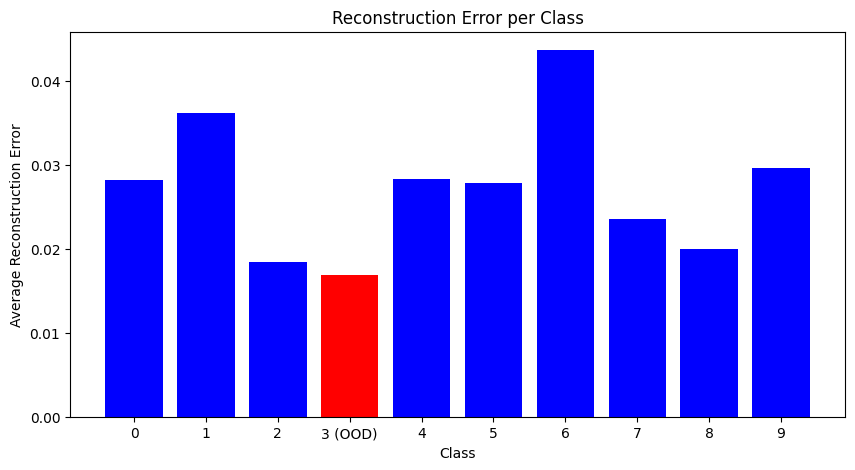

In [41]:
digits = list(digit_losses.keys())
losses_plot = list(digit_losses.values())

colors = ["red" if d == OOD_CLASS else "blue" for d in digits]

plt.figure(figsize=(10,5))
plt.bar(digits, losses_plot, color=colors)
plt.xlabel("Class")
plt.ylabel("Average Reconstruction Error")
plt.title("Reconstruction Error per Class")
plt.xticks(digits, [f"{d} (OOD)" if d == OOD_CLASS else str(d) for d in digits])

plt.show()

### plotting original and reconstructed images

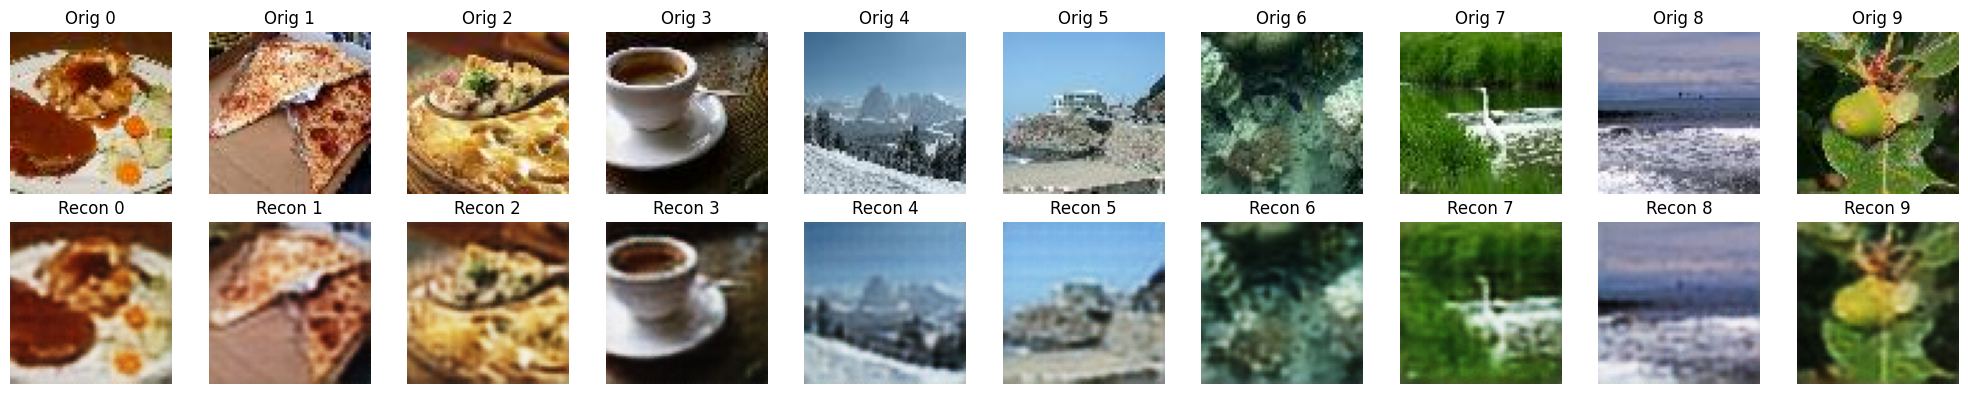

In [42]:
model.eval()

fig, axes = plt.subplots(2,10, figsize=(20,4))
samples_per_class = {}

# collect one sample per class
for imgs, labels in test_loader_seen:
    for img, label in zip(imgs, labels):
        if label.item() not in samples_per_class:
            samples_per_class[label.item()] = img
    if len(samples_per_class) >= 9:
        break

# include unseen class sample
for imgs, labels in test_loader_unseen:
    for img, label in zip(imgs, labels):
        samples_per_class[label.item()] = img
        break
    break

with torch.no_grad():
    for d in range(len(train_dataset.classes)):
        img = samples_per_class[d]
        original = img.permute(1,2,0).cpu().numpy()
        recon = model(img.unsqueeze(0).to(device)).squeeze(0)
        reconstructed = recon.permute(1,2,0).cpu().numpy()

        # denormalize for visualization
        original = (original * 0.5) + 0.5
        reconstructed = (reconstructed * 0.5) + 0.5

        axes[0,d].imshow(original)
        axes[0,d].set_title(f"Orig {d}")
        axes[0,d].axis("off")
        axes[1,d].imshow(reconstructed)
        axes[1,d].set_title(f"Recon {d}")
        axes[1,d].axis("off")

plt.tight_layout()
plt.show()

In [45]:
num_classes = len(train_dataset.classes)

# stores list of losses for each class across runs
all_class_losses = {c: [] for c in range(num_classes)}

In [46]:
for OOD_CLASS in range(num_classes):

    print(f"\n=== Training with OOD class {OOD_CLASS} ===")

    train_indices_seen = []
    test_indices_seen = []
    test_indices_unseen = []

    for i, (_, label) in enumerate(train_dataset):
        if label != OOD_CLASS:
            train_indices_seen.append(i)

    for i, (_, label) in enumerate(test_dataset):
        if label == OOD_CLASS:
            test_indices_unseen.append(i)
        else:
            test_indices_seen.append(i)

    train_seen = Subset(train_dataset, train_indices_seen)
    test_seen = Subset(test_dataset, test_indices_seen)
    test_unseen = Subset(test_dataset, test_indices_unseen)

    batch_size = 128
    
    train_loader = DataLoader(train_seen, batch_size=batch_size, shuffle=True)
    test_loader_seen = DataLoader(test_seen, batch_size=batch_size)
    test_loader_unseen = DataLoader(test_unseen, batch_size=batch_size)

    # model
    model = ConvAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # train
    for epoch in range(10):
        model.train()
        for imgs, _ in train_loader:
            x = imgs.to(device)
            loss = criterion(model(x), x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # evaluation
    model.eval()

    all_losses = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels in test_loader_seen:
            x = imgs.to(device)
            recon = model(x)
            err = torch.mean((recon - x)**2, dim=(1,2,3))

            all_losses.extend(err.cpu().numpy())
            all_labels.extend(labels.numpy())

        for imgs, labels in test_loader_unseen:
            x = imgs.to(device)
            recon = model(x)
            err = torch.mean((recon - x)**2, dim=(1,2,3))

            all_losses.extend(err.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_losses = np.array(all_losses)
    all_labels = np.array(all_labels)

    # per class loss
    for c in range(num_classes):
        class_loss = all_losses[all_labels == c].mean()
        all_class_losses[c].append(class_loss)


=== Training with OOD class 0 ===

=== Training with OOD class 1 ===

=== Training with OOD class 2 ===

=== Training with OOD class 3 ===

=== Training with OOD class 4 ===

=== Training with OOD class 5 ===

=== Training with OOD class 6 ===

=== Training with OOD class 7 ===

=== Training with OOD class 8 ===

=== Training with OOD class 9 ===


In [47]:
mean_losses = []
var_losses = []

for c in range(num_classes):
    values = np.array(all_class_losses[c])

    mean_losses.append(values.mean())
    var_losses.append(values.var())

    print(f"Class {c}: Mean={values.mean():.6f}, Var={values.var():.6f}")

Class 0: Mean=0.043255, Var=0.000002
Class 1: Mean=0.054327, Var=0.000002
Class 2: Mean=0.030177, Var=0.000001
Class 3: Mean=0.028947, Var=0.000001
Class 4: Mean=0.039932, Var=0.000001
Class 5: Mean=0.038491, Var=0.000001
Class 6: Mean=0.063730, Var=0.000005
Class 7: Mean=0.035143, Var=0.000001
Class 8: Mean=0.029017, Var=0.000001
Class 9: Mean=0.048054, Var=0.000008


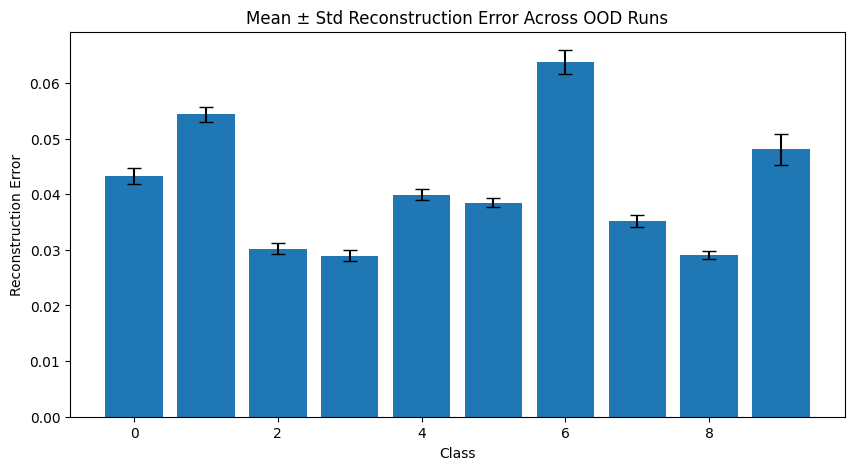

In [48]:
classes = list(range(num_classes))

std_losses = np.sqrt(var_losses)

plt.figure(figsize=(10,5))

plt.bar(classes, mean_losses, yerr=std_losses, capsize=5)

plt.xlabel("Class")
plt.ylabel("Reconstruction Error")
plt.title("Mean ± Std Reconstruction Error Across OOD Runs")

plt.show()